In [1]:
# Load libraries
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.dates import MonthLocator
import matplotlib.ticker as mtick
import os
import json
import sys
import datetime
from datetime import date, timedelta
from matplotlib.dates import MO, WeekdayLocator, MonthLocator, YearLocator
from datetime import datetime, UTC, date
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates
from matplotlib.dates import AutoDateLocator, ConciseDateFormatter, MO
from IPython.display import HTML
from matplotlib.ticker import PercentFormatter, StrMethodFormatter

plots_filepath = 'plots/august-25/'

# Append utils to path for logo import
sys.path.append("utils")
from logo import add_logo

def format_date_with_suffix(date_obj):
    # 1) turn str or datetime/date into a pd.Timestamp
    ts = pd.to_datetime(date_obj)

    # 2) get the day and compute the ordinal suffix
    day = ts.day
    if 10 <= day % 100 <= 20:
        suffix = 'th'
    else:
        suffix = {1: 'st', 2: 'nd', 3: 'rd'}.get(day % 10, 'th')

    # 3) build the final string
    #    Month name: ts.strftime('%B')
    #    Day + suffix: f'{day}{suffix}'
    #    Year: ts.year
    return f"{ts.strftime('%B')} {day}{suffix}, {ts.year}"


today = datetime.today()
date = format_date_with_suffix(today)

In [2]:
# Function to stablecoin mcap
def stablecoin_mcap_by_chain(asset, start_date, end_date, n):
    chain_colors = ['#1f1f60',
                    '#191F98',
                    '#313EA5',
                    '#4A5DB2',
                    '#637BBF',
                    '#7C9ACC',
                    '#94B9D9',
                    '#ADD8E6',
                    '#333333',
                    '#494949',
                    '#5F5F5F',
                    '#757575',
                    '#8A8A8A',
                    '#A0A0A0',
                    '#B6B6B6',
                    '#CCCCCC'
                   ]
    
    df_master = None
    
    counter = 0
    
    start_date_dt = pd.to_datetime(start_date)
    end_date_dt = pd.to_datetime(end_date) - pd.Timedelta(days=1)

    with open(f"raw-data/defillama-raw-data/stablecoins/{asset}.json", 'r') as f:
        data = json.load(f)
    
    # Flatten records
    records = []
    for chain, chain_data in data.get('chainBalances', {}).items():
        for entry in chain_data.get('tokens', []):
            df_date = pd.to_datetime(entry.get('date'), unit='s')
            # Use circulating peggedUSD; if missing, fallback to bridgedTo peggedUSD
            value = entry.get('circulating', {}).get('peggedUSD')
            if value is None:
                value = entry.get('bridgedTo', {}).get('peggedUSD', 0)
            records.append({'date': df_date, 'chain': chain, 'peggedUSD': value})
    
    # Create DataFrame and pivot
    df_all = pd.DataFrame(records)
    df_pivot = df_all.pivot_table(index='date', columns='chain', values='peggedUSD', aggfunc='sum')
    df_pivot = df_pivot.ffill().sort_index()
    
    # Determine top_n chains *by the last date* in the index
    last_date   = df_pivot.index.max()
    last_values = df_pivot.loc[last_date]
    sorted_chains = last_values.sort_values(ascending=False)
    top_chains  = list(sorted_chains.index[:n])
    other_chains = list(sorted_chains.index[n:])
    
    # Build final DataFrame with 'Other' aggregation
    df_top = df_pivot[top_chains].copy()
    df_top['Other'] = df_pivot[other_chains].sum(axis=1)
    df_master = df_top.reset_index()

    # Filter by appropriate dates
    df_master = df_master.loc[(df_master['date'] >= start_date_dt) &
    (df_master['date'] < end_date_dt)
    ]
        
    # Sort your master dataframe by date
    df_master = df_master.sort_values('date')

    # Grab chain names
    chains = df_master.columns[1:].tolist()

    # Calculate 7-day trailing averages for each chain column
    df_master[chains] = df_master[chains].rolling(window=7, min_periods=1).mean()
    
    # Prepare the values and colors in the right order
    dates   = df_master['date']
    series  = [df_master[chain] for chain in chains]
    
    # Create color mapping with special case for Hyperliquid L1
    colors = []
    color_index = 0
    for chain in chains:
        if chain == 'Hyperliquid L1':
            colors.append('#09b882')
        else:
            colors.append(chain_colors[color_index % len(chain_colors)])
            color_index += 1
    
    # Plot a single stacked‐area call
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.stackplot(
        dates,
        *series,
        labels=chains,
        colors=colors
    )
    
    ax.yaxis.set_major_formatter(mtick.FuncFormatter(lambda x, _: f'${x/1000000000:.0f}b'))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    plt.xticks(rotation=45)
    
    ax.legend(loc='upper left', bbox_to_anchor=(0,1), ncol=2)
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    add_logo(ax, position=(0.08, -0.18))
    ax.margins(x=0)
    plt.figtext(0.12, -0.11, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: DefiLlama", ha='left', fontsize=10, style='italic')
    ax.set_title(f'{asset} Market Cap by Chain')
    
    # Save plot
    if not os.path.exists("plots"):
        os.makedirs("plots")
    plt.savefig(f"{plots_filepath}/{asset}-mcap-by-chain.png", dpi=300, bbox_inches='tight')
    plt.show()
    
    print(df_master.tail(5))

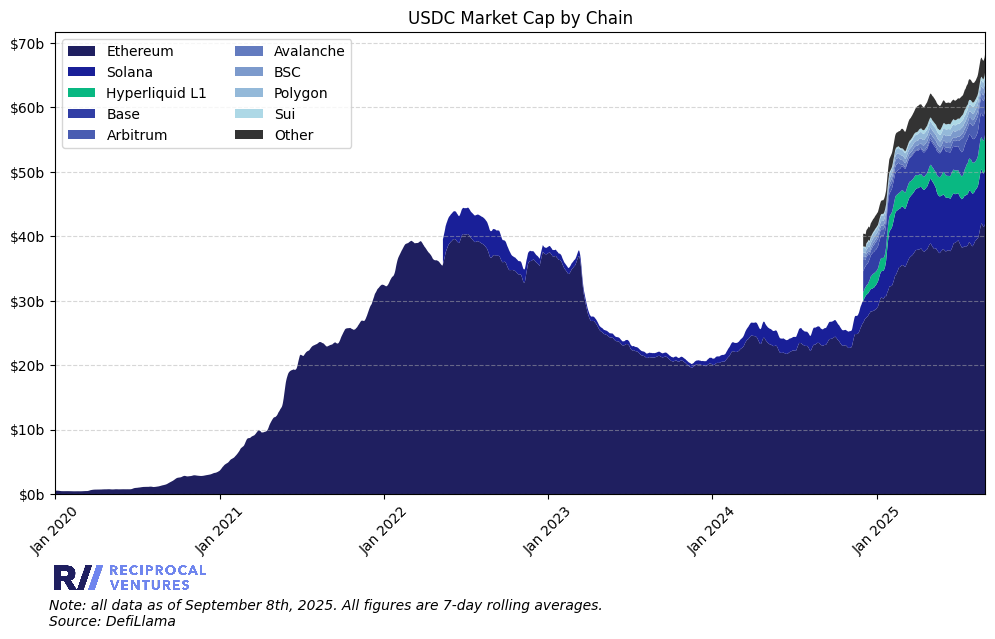

chain       date      Ethereum        Solana  Hyperliquid L1          Base  \
2540  2025-08-25  4.146821e+10  8.274973e+09    5.062522e+09  3.805697e+09   
2541  2025-08-26  4.148409e+10  8.303230e+09    5.105956e+09  3.831846e+09   
2542  2025-08-27  4.154715e+10  8.353530e+09    5.201396e+09  3.860325e+09   
2543  2025-08-28  4.164449e+10  8.409655e+09    5.295579e+09  3.882750e+09   
2544  2025-08-29  4.201316e+10  8.478367e+09    5.364923e+09  3.905806e+09   

chain      Arbitrum     Avalanche           BSC       Polygon           Sui  \
2540   2.378676e+09  8.720059e+08  1.032680e+09  9.319102e+08  5.165953e+08   
2541   2.347879e+09  9.234165e+08  1.039817e+09  9.440494e+08  5.134004e+08   
2542   2.269946e+09  9.746624e+08  1.039804e+09  9.539077e+08  5.123581e+08   
2543   2.193703e+09  1.025536e+09  1.039794e+09  9.658357e+08  5.157034e+08   
2544   2.120493e+09  1.068509e+09  1.039780e+09  9.771646e+08  5.280751e+08   

chain         Other  
2540   2.874520e+09  
2541   2.845

In [3]:
asset = 'USDC'
start_date = '2020-01-01'
end_date = today
n = 9 # number of protocols to show, max is number pulled down in the raw data

stablecoin_mcap_by_chain(asset, start_date, end_date, n)

In [59]:
def hyperliquid_as_percent_of_total_usdc(dune_path, messari_path, start_date):
    # Load dune data
    with open(dune_path, 'r') as f:
        dune_data = json.load(f)
    rows = dune_data['result']['rows']
    dune_df = pd.DataFrame(rows)

    # To datetime
    dune_df['date'] = pd.to_datetime(dune_df['date'], format='%Y-%m-%d %H:%M:%S.%f UTC').dt.normalize()
    
    # Load messari data
    with open(messari_path, 'r') as f:
        messari_data = json.load(f)

    points = messari_data['data']['points']
    messari_df = pd.DataFrame(points, columns=[
        'timestamp',
        'circulating-marketcap',
        'circulating-marketcap-dominance',
        'fully-diluted-marketcap'
    ])

    messari_df["date"] = pd.to_datetime(messari_df["timestamp"], unit="s").dt.normalize().ffill()
    messari_df = messari_df[['date','fully-diluted-marketcap']]
    messari_df['USDC Supply'] = messari_df['fully-diluted-marketcap'].rolling(window=7, min_periods=1).mean()

    # Merge datasets for asset slug
    df = pd.merge(messari_df, dune_df, on="date", how="inner")

    # Cut off df to only be after start date
    df = df[df['date'] >= start_date]

    # Calculate Hyperliquid as % of total
    df['USDC on Hyperliquid (Percent of Total)'] = (df['cumulative_amount'] / df['USDC Supply']).rolling(window=7, min_periods=1).mean()


    # Plot
    fig, ax1 = plt.subplots(figsize=(12, 6))

    ax2 = ax1.twinx()

    # Set ax2 to be behind ax1, but make ax1 background transparent
    ax2.set_zorder(1)  # ax2 behind
    ax1.set_zorder(2)  # ax1 in front
    ax1.patch.set_visible(False)  # Make ax1 background transparent
    
    # Line: OI
    ax1.plot(
        df["date"], df["USDC Supply"],
        color="#1f1f60", linewidth=2,
        label="Total USDC Supply",
        zorder=2
    )
    ax1.set_ylabel("Total USDC Supply")
    ax1.yaxis.set_major_formatter(
            mtick.FuncFormatter(lambda x, _: f'${x/1e9:,.0f}b'))
    ax1.set_ylim(bottom=0)
    ax1.margins(x=0)                  # no extra padding

    # Monthly ticks, lighter crowding
    ax1.xaxis.set_major_locator(MonthLocator())
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
  
    plt.setp(ax1.get_xticklabels(), rotation=45, ha="right")

    # Area: USDC on Hyperliquid (Percent of Total) 
    ax2.fill_between(
        df["date"], df["USDC on Hyperliquid (Percent of Total)"],
        color="#a4a2a8", alpha=1,
        label="USDC on Hyperliquid (Percent of Total)",
        zorder=1
    )
    ax2.yaxis.set_major_formatter(
            mtick.FuncFormatter(lambda x, _: f'{x*100:,.0f}%'))
    
    ax2.set_ylabel("Percent of Total USDC Supply")
    ax2.margins(x=0)                  # no extra padding
    ax2.set_ylim(bottom=0)

    # Monthly ticks, lighter crowding
    ax2.xaxis.set_major_locator(MonthLocator())
    ax2.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
    
    # Title, grid & legend
    ax1.set_title(f"USDC: Hyperliquid vs Total Supply", fontsize=14)
    ax1.grid(axis="y", linestyle="--", alpha=0.5)
    h1, l1 = ax1.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax1.legend(h1 + h2, l1 + l2, loc="upper left")
    
    # Save & show
    add_logo(ax1, position=(0.075, -0.21))
    plt.figtext(0.075, -0.02, f"Note: all data as of {date}. All figures are 7-day rolling averages.\nSource: Dune Analytics and Messari", ha='left', fontsize=10, style='italic')
    plt.tight_layout()
    plt.savefig(f"{plots_filepath}/hyperliquid_usdc_supply.png", dpi=300, bbox_inches="tight")
    plt.show()
    
    # Debug print
    print(df.tail(5))
    




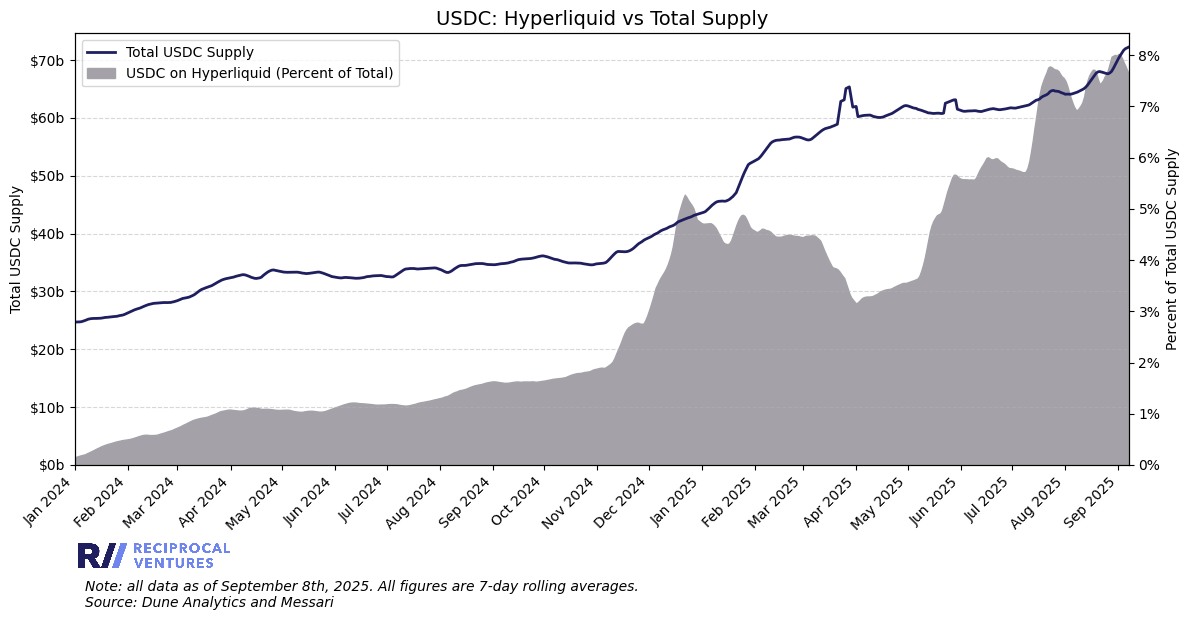

          date  fully-diluted-marketcap   USDC Supply        amount  \
640 2025-09-03             7.216486e+10  7.119063e+10  1.586415e+06   
641 2025-09-04             7.268391e+10  7.166700e+10 -6.219456e+07   
642 2025-09-05             7.258597e+10  7.194638e+10  4.444581e+07   
643 2025-09-06             7.256140e+10  7.208971e+10  6.777438e+06   
644 2025-09-07             7.255597e+10  7.223333e+10 -3.718013e+07   

     cumulative_amount  USDC on Hyperliquid (Percent of Total)  
640       5.454507e+09                                0.079457  
641       5.392313e+09                                0.078643  
642       5.436759e+09                                0.077926  
643       5.443536e+09                                0.077121  
644       5.406356e+09                                0.076356  


In [60]:
# Call the function
dune_path = 'raw-data/dune-raw-data/hyperliquid-usdc-supply.json'
messari_path = 'raw-data/messari-raw-data/asset-data/usdc_marketcap.json'
start_date = '2024-01-01'

hyperliquid_as_percent_of_total_usdc(dune_path, messari_path, start_date)